In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# %pip install scikit-learn==1.3.2 matplotlib seaborn
# Optional heavies:
%pip install xgboost transformers accelerate datasets -q

In [ ]:
import os, math, json
import numpy as np
import pandas as pd
from pathlib import Path

from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support, roc_auc_score,
    confusion_matrix, classification_report
)
from sklearn.preprocessing import label_binarize
from scipy.special import expit  # stable logistic
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier

import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# -------------------
# Toggles / Paths
# -------------------
SEED = 42
np.random.seed(SEED)

# Point these to Phase 3 outputs:
DATA_DIR = "/content/drive/MyDrive/MSIS-822-Project/v2/data/03_phase3_features"
TRAIN_CSV = f"{DATA_DIR}/phase3_train_features.csv"
VAL_CSV   = f"{DATA_DIR}/phase3_val_features.csv"
TEST_CSV  = f"{DATA_DIR}/phase3_test_features.csv"

# Label / text columns
LABEL_COL = "label"           # int or string
TEXT_COL  = "text_clean"      # used only if BERT fine-tuning is enable

# Models toggles
RUN_BASELINES = True
RUN_TRADITIONAL = True
RUN_MLP = True       # Simple neural net on numeric features
RUN_BERT = True     # Heavier; enable only if GPU + time

# XGBoost optional
USE_XGBOOST = True
if USE_XGBOOST:
    try:
        import xgboost as xgb
    except Exception as e:
        print("[warn] xgboost not available; disabling")
        USE_XGBOOST = False

# Plot style
sns.set(context="notebook", style="whitegrid")

# Load data & define features

In [ ]:
# -------------------
# Load split data
# -------------------
train_df = pd.read_csv(TRAIN_CSV)
val_df   = pd.read_csv(VAL_CSV)
test_df  = pd.read_csv(TEST_CSV)

# Sanity checks
for name, df in [("train", train_df), ("val", val_df), ("test", test_df)]:
    assert "split_name" in df.columns, f"{name} missing split_name"
    assert LABEL_COL in df.columns, f"{name} missing label col '{LABEL_COL}'"

# -------------------
# Feature columns = engineered features from Phase 3
# -------------------
FEAT_COLS = [
    "f001_total_chars",
    "f004_ws_over_C",
    "f013_hapax_ratio",
    "f022_entropy_wordfreq",
    "f025_single_quotes",
    "f034_total_sentences",
    "f043_num_nouns",
    "f046_num_adverbs",
    "f055_noun_to_verb_ratio",
    "f064_num_nominatives",
    "f067_num_singular",
    "f076_num_passive_sentences",
    "f085_sent_len_variance",
    "f088_sem_sim_sentences",
    "f097_bert_sim_tokens",
    "f106_tanween_freq",
    "f109_link_freq"
]

# Keep only available features (if some were disabled upstream)
FEAT_COLS = [c for c in FEAT_COLS if c in train_df.columns]

print("Using features:", FEAT_COLS)

# -------------------
# Build matrices
# -------------------
def make_xy(df):
    X = df[FEAT_COLS].copy()
    y = df[LABEL_COL].copy()
    # Ensure numeric dtype and finite values (replace inf/nan)
    X = X.replace([np.inf, -np.inf], np.nan).fillna(0.0).astype(float)
    return X, y

X_tr, y_tr = make_xy(train_df)
X_va, y_va = make_xy(val_df)
X_te, y_te = make_xy(test_df)

# Label stats
print("Train size:", X_tr.shape, "Val size:", X_va.shape, "Test size:", X_te.shape)
print("Classes:", sorted(pd.unique(pd.concat([y_tr, y_va, y_te]))))


Using features: ['f001_total_chars', 'f004_ws_over_C', 'f013_hapax_ratio', 'f022_entropy_wordfreq', 'f025_single_quotes', 'f034_total_sentences', 'f043_num_nouns', 'f046_num_adverbs', 'f055_noun_to_verb_ratio', 'f064_num_nominatives', 'f067_num_singular', 'f076_num_passive_sentences', 'f085_sent_len_variance', 'f088_sem_sim_sentences', 'f097_bert_sim_tokens', 'f106_tanween_freq', 'f109_link_freq']
Train size: (29355, 17) Val size: (6290, 17) Test size: (6291, 17)
Classes: [np.int64(0), np.int64(1)]


# Metrics helper & plots

In [ ]:
# -------------------
# Metrics helpers
# -------------------
def eval_on_split(model, X, y, average="macro", label_names=None):
    y_pred = model.predict(X)
    acc = accuracy_score(y, y_pred)
    p, r, f1, _ = precision_recall_fscore_support(y, y_pred, average=average, zero_division=0)
    report = classification_report(y, y_pred, zero_division=0, target_names=label_names)
    return {"acc":acc, "prec":p, "rec":r, "f1":f1, "report":report, "y_pred":y_pred}

def plot_confusion(y_true, y_pred, title="Confusion Matrix"):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(title)
    plt.ylabel("True")
    plt.xlabel("Pred")
    plt.tight_layout()
    plt.show()

def show_eval(name, res, y_true):
    print(f"\n[{name}] Accuracy: {res['acc']:.4f} | Precision: {res['prec']:.4f} | Recall: {res['rec']:.4f} | F1: {res['f1']:.4f}")
    print(res["report"])
    plot_confusion(y_true, res["y_pred"], title=f"{name} — Confusion Matrix")


In [ ]:
def maybe_roc_auc(model, X, y):
    """Robust ROC-AUC for binary or multiclass.
    - Uses predict_proba when available.
    - Falls back to decision_function (binary: expit(margin); multiclass: OvR margins).
    - Returns np.nan if y has <2 classes in this split.
    """
    y = np.asarray(y)
    classes = np.unique(y)
    if classes.size < 2:
        return np.nan  # can't compute AUC with one class present

    # 1) Preferred: probabilities
    if hasattr(model, "predict_proba"):
        proba = model.predict_proba(X)
        # Binary: use positive-class probability
        if proba.ndim == 2 and proba.shape[1] == 2 and classes.size == 2:
            return roc_auc_score(y, proba[:, 1])
        # Multiclass: macro OvR
        y_bin = label_binarize(y, classes=classes)
        return roc_auc_score(y_bin, proba, average="macro", multi_class="ovr")

    # 2) Fallback: decision_function scores
    if hasattr(model, "decision_function"):
        scores = model.decision_function(X)
        # Binary: 1-D margins → map to (0,1) monotonically
        if scores.ndim == 1 and classes.size == 2:
            return roc_auc_score(y, expit(scores))
        # Multiclass: OvR margins per class (shape: n_samples x n_classes)
        if scores.ndim == 2:
            y_bin = label_binarize(y, classes=classes)
            return roc_auc_score(y_bin, scores, average="macro", multi_class="ovr")
        # Edge-case: single-column 2D -> squeeze and treat as binary
        if scores.ndim == 2 and scores.shape[1] == 1 and classes.size == 2:
            return roc_auc_score(y, expit(scores.ravel()))

    # 3) No usable scoring interface
    return np.nan

# Task 4.1 — Baseline models


[Baseline: Logistic Regression (val)] Accuracy: 0.9556 | Precision: 0.9447 | Recall: 0.9139 | F1: 0.9282
              precision    recall  f1-score   support

           0       0.93      0.84      0.88      1258
           1       0.96      0.98      0.97      5032

    accuracy                           0.96      6290
   macro avg       0.94      0.91      0.93      6290
weighted avg       0.96      0.96      0.95      6290



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


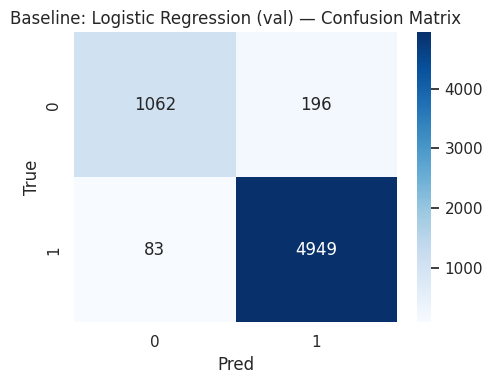


[Baseline: GaussianNB (val)] Accuracy: 0.9192 | Precision: 0.9137 | Recall: 0.8240 | F1: 0.8592
              precision    recall  f1-score   support

           0       0.91      0.67      0.77      1258
           1       0.92      0.98      0.95      5032

    accuracy                           0.92      6290
   macro avg       0.91      0.82      0.86      6290
weighted avg       0.92      0.92      0.91      6290



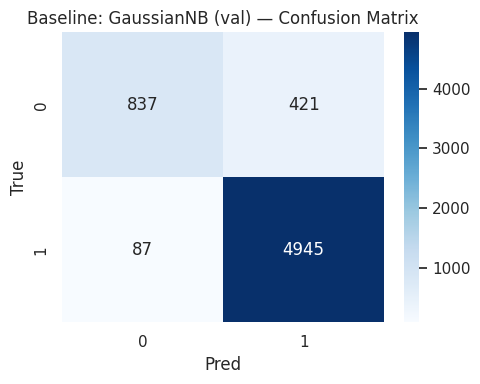

Best baseline: LogReg


In [ ]:
baseline_results = {}

if RUN_BASELINES:
    # Logistic Regression (with scaling)
    lr_pipe = Pipeline([
        ("scaler", StandardScaler(with_mean=False)),  # with_mean=False handles sparse-like safety
        ("clf", LogisticRegression(
            max_iter=200, class_weight=None, random_state=SEED, n_jobs=None
        ))
    ])
    lr_pipe.fit(X_tr, y_tr)
    val_lr = eval_on_split(lr_pipe, X_va, y_va)
    baseline_results["LogReg"] = val_lr
    show_eval("Baseline: Logistic Regression (val)", val_lr, y_va)

    # Gaussian Naive Bayes (no scaling; expects dense)
    nb = GaussianNB()
    nb.fit(X_tr.values, y_tr.values)
    val_nb = eval_on_split(nb, X_va.values, y_va.values)
    baseline_results["GaussianNB"] = val_nb
    show_eval("Baseline: GaussianNB (val)", val_nb, y_va)

# Pick best baseline by validation F1
best_baseline_name = max(baseline_results, key=lambda k: baseline_results[k]["f1"]) if baseline_results else None
print("Best baseline:", best_baseline_name)


# Task 4.2 — Traditional ML (SVM, RF / XGBoost)

SVM best params: {'clf__C': 1.0}

[Traditional: LinearSVC (val)] Accuracy: 0.9545 | Precision: 0.9474 | Recall: 0.9075 | F1: 0.9257
              precision    recall  f1-score   support

           0       0.94      0.83      0.88      1258
           1       0.96      0.99      0.97      5032

    accuracy                           0.95      6290
   macro avg       0.95      0.91      0.93      6290
weighted avg       0.95      0.95      0.95      6290



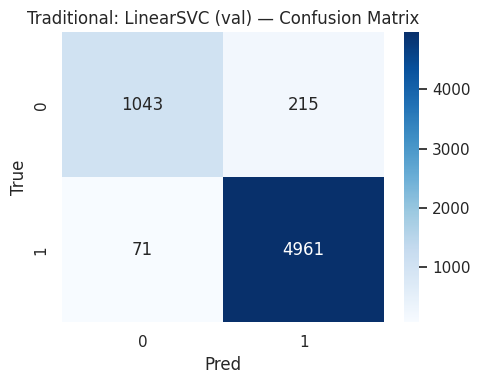

RF best params: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}

[Traditional: RandomForest (val)] Accuracy: 0.9857 | Precision: 0.9708 | Recall: 0.9857 | F1: 0.9780
              precision    recall  f1-score   support

           0       0.95      0.99      0.96      1258
           1       1.00      0.99      0.99      5032

    accuracy                           0.99      6290
   macro avg       0.97      0.99      0.98      6290
weighted avg       0.99      0.99      0.99      6290



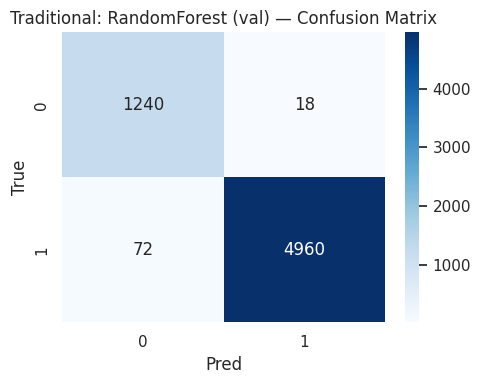

/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


XGB best params: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 6, 'subsample': 0.8}

[Traditional: XGBoost (val)] Accuracy: 0.9841 | Precision: 0.9688 | Recall: 0.9826 | F1: 0.9755
              precision    recall  f1-score   support

           0       0.94      0.98      0.96      1258
           1       0.99      0.99      0.99      5032

    accuracy                           0.98      6290
   macro avg       0.97      0.98      0.98      6290
weighted avg       0.98      0.98      0.98      6290



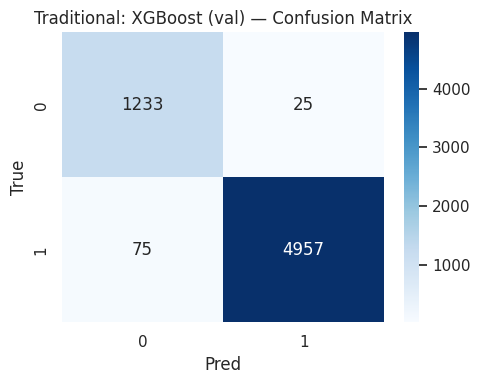

Best traditional: RandomForest | F1(val) = 0.978


In [ ]:
traditional_results = {}

if RUN_TRADITIONAL:
    # ---- Linear SVM ----
    svm_pipe = Pipeline([
        ("scaler", StandardScaler(with_mean=False)),
        ("clf", LinearSVC(random_state=SEED))
    ])
    svm_grid = {"clf__C": [0.25, 0.5, 1.0, 2.0]}
    svm_gs = GridSearchCV(svm_pipe, svm_grid, scoring="f1_macro", cv=3, n_jobs=-1, verbose=0)
    svm_gs.fit(X_tr, y_tr)
    svm_best = svm_gs.best_estimator_
    val_svm = eval_on_split(svm_best, X_va, y_va)
    traditional_results["LinearSVC"] = {"model": svm_best, "val": val_svm, "best_params": svm_gs.best_params_}
    print("SVM best params:", svm_gs.best_params_)
    show_eval("Traditional: LinearSVC (val)", val_svm, y_va)

    # ---- Random Forest ----
    rf = RandomForestClassifier(random_state=SEED, n_jobs=-1)
    rf_grid = {
        "n_estimators": [200, 400],
        "max_depth": [None, 20, 40],
        "min_samples_split": [2, 5],
        "min_samples_leaf": [1, 2]
    }
    rf_gs = GridSearchCV(rf, rf_grid, scoring="f1_macro", cv=3, n_jobs=-1, verbose=0)
    rf_gs.fit(X_tr, y_tr)
    rf_best = rf_gs.best_estimator_
    val_rf = eval_on_split(rf_best, X_va, y_va)
    traditional_results["RandomForest"] = {"model": rf_best, "val": val_rf, "best_params": rf_gs.best_params_}
    print("RF best params:", rf_gs.best_params_)
    show_eval("Traditional: RandomForest (val)", val_rf, y_va)

    # ---- XGBoost (optional) ----
    if USE_XGBOOST:
        xgb_clf = xgb.XGBClassifier(
            objective="multi:softprob" if len(np.unique(y_tr))>2 else "binary:logistic",
            eval_metric="mlogloss", random_state=SEED, n_estimators=400, tree_method="hist"
        )
        xgb_grid = {"max_depth":[4,6], "learning_rate":[0.05, 0.1], "subsample":[0.8,1.0], "colsample_bytree":[0.8,1.0]}
        xgb_gs = GridSearchCV(xgb_clf, xgb_grid, scoring="f1_macro", cv=3, n_jobs=-1, verbose=0)
        xgb_gs.fit(X_tr, y_tr)
        xgb_best = xgb_gs.best_estimator_
        val_xgb = eval_on_split(xgb_best, X_va, y_va)
        traditional_results["XGBoost"] = {"model": xgb_best, "val": val_xgb, "best_params": xgb_gs.best_params_}
        print("XGB best params:", xgb_gs.best_params_)
        show_eval("Traditional: XGBoost (val)", val_xgb, y_va)

# Pick best traditional model by validation F1
best_trad_name = None
best_trad_model = None
best_trad_f1 = -1
for name, pack in traditional_results.items():
    f1 = pack["val"]["f1"]
    if f1 > best_trad_f1:
        best_trad_f1 = f1
        best_trad_name = name
        best_trad_model = pack["model"]

print("Best traditional:", best_trad_name, "| F1(val) =", round(best_trad_f1, 4))


# Task 4.3 — Deep Learning

##  A: MLP on numeric features (fast)


[Deep (MLP on numeric feats) — (val)] Accuracy: 0.9638 | Precision: 0.9450 | Recall: 0.9413 | F1: 0.9431
              precision    recall  f1-score   support

           0       0.91      0.90      0.91      1258
           1       0.98      0.98      0.98      5032

    accuracy                           0.96      6290
   macro avg       0.95      0.94      0.94      6290
weighted avg       0.96      0.96      0.96      6290



/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(


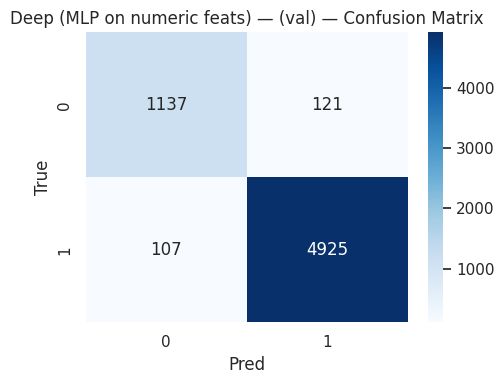

In [ ]:
mlp_result = None
mlp_model = None

if RUN_MLP:
    from sklearn.neural_network import MLPClassifier

    # Standardize -> MLP
    mlp_pipe = Pipeline([
        ("scaler", StandardScaler(with_mean=False)),
        ("clf", MLPClassifier(
            hidden_layer_sizes=(128, 64),
            activation="relu",
            solver="adam",
            alpha=1e-4,
            batch_size=256,
            learning_rate_init=1e-3,
            max_iter=20,  # small for speed; increase if you can
            random_state=SEED
        ))
    ])
    mlp_pipe.fit(X_tr, y_tr)
    val_mlp = eval_on_split(mlp_pipe, X_va, y_va)
    mlp_model = mlp_pipe
    mlp_result = val_mlp
    show_eval("Deep (MLP on numeric feats) — (val)", val_mlp, y_va)


# B: BERT fine-tuning (heavier; optional)


In [ ]:
bert_val_result = None
bert_model_path = None

if RUN_BERT:
    import torch
    from datasets import Dataset as HFDataset
    from transformers import (
        AutoTokenizer,
        AutoModelForSequenceClassification,
        TrainingArguments,
        Trainer,
        set_seed,
    )

    # -------------------- GPU / precision config --------------------
    set_seed(SEED)
    USE_CUDA = torch.cuda.is_available()
    device = torch.device("cuda" if USE_CUDA else "cpu")
    print(">> Using", device, "with float16 mixed precision" if device=="cuda" else "")


    # -------------------- data prep (train/val only) --------------------
    model_name = "aubmindlab/bert-base-arabertv02"
    num_labels = len(np.unique(pd.concat([y_tr, y_va])))

    def make_hf(df):
        # Use 'labels' column name for Trainer
        return HFDataset.from_pandas(
            df[[TEXT_COL, LABEL_COL]].rename(columns={TEXT_COL: "text", LABEL_COL: "labels"}),
            preserve_index=False
        )

    hf_train = make_hf(train_df)
    hf_val   = make_hf(val_df)

    tokenizer = AutoTokenizer.from_pretrained(model_name)

    def tok(batch):
        return tokenizer(batch["text"], truncation=True, padding="max_length", max_length=256)

    hf_train = hf_train.map(tok, batched=True)
    hf_val   = hf_val.map(tok, batched=True)

    hf_train.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])
    hf_val.set_format(type="torch",   columns=["input_ids", "attention_mask", "labels"])

    # -------------------- model --------------------
    model = AutoModelForSequenceClassification.from_pretrained(
        model_name,
        num_labels=num_labels,
        dtype=torch.float16 if device=="cuda" else None,   # modern arg; falls back automatically if CPU
    )
    # Memory savings on GPU
    model.gradient_checkpointing_enable()
    model.to(device)

    # -------------------- training args --------------------
    args = TrainingArguments(
        output_dir="/content/drive/MyDrive/MSIS-822-Project/v2/models/bert_cls",
        per_device_train_batch_size=16 if USE_CUDA else 8,
        per_device_eval_batch_size=16 if USE_CUDA else 8,

        eval_strategy="epoch",
        save_strategy="epoch",
        learning_rate=2e-5,
        num_train_epochs=2,              # consider 3–5 if time allows
        weight_decay=0.01,
        load_best_model_at_end=True,
        metric_for_best_model="f1",
        greater_is_better=True,

        seed=SEED,
        fp16=(USE_CUDA),
        dataloader_num_workers=2,
        report_to="none",
        logging_steps=50,
    )

    # -------------------- metrics --------------------
    from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score

    def compute_metrics(eval_pred):
        logits, labels = eval_pred
        preds = np.argmax(logits, axis=1)
        return {
            "accuracy":  accuracy_score(labels, preds),
            "precision": precision_score(labels, preds, average="macro", zero_division=0),
            "recall":    recall_score(labels, preds, average="macro", zero_division=0),
            "f1":        f1_score(labels, preds, average="macro", zero_division=0),
        }

    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=hf_train,
        eval_dataset=hf_val,
        tokenizer=tokenizer,
        compute_metrics=compute_metrics,
    )

    # -------------------- train / evaluate --------------------
    trainer.train()
    metrics = trainer.evaluate(hf_val)
    print("BERT (val) metrics:", metrics)


>> Using cuda 


Map:   0%|          | 0/29355 [00:00<?, ? examples/s]

Map:   0%|          | 0/6290 [00:00<?, ? examples/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at aubmindlab/bert-base-arabertv02 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-2475971140.py:92: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.047100,0.057432,0.985374,0.972969,0.981916,0.977361
2,0.035300,0.059621,0.986169,0.980749,0.975855,0.978278


BERT (val) metrics: {'eval_loss': 0.059620775282382965, 'eval_accuracy': 0.9861685214626391, 'eval_precision': 0.9807489344153325, 'eval_recall': 0.9758545310015898, 'eval_f1': 0.9782779891045794, 'eval_runtime': 21.9092, 'eval_samples_per_second': 287.094, 'eval_steps_per_second': 17.983, 'epoch': 2.0}


Parameter 'function'=<function BertWrapper._to_ds.<locals>.<lambda> at 0x7cca8326f6a0> of the transform datasets.arrow_dataset.Dataset._map_single couldn't be hashed properly, a random hash was used instead. Make sure your transforms and parameters are serializable with pickle or dill for the dataset fingerprinting and caching to work. If you reuse this transform, the caching mechanism will consider it to be different from the previous calls and recompute everything. This warning is only showed once. Subsequent hashing failures won't be showed.


Map:   0%|          | 0/6290 [00:00<?, ? examples/s]


[Deep (BERT fine-tuned) — (val)] Accuracy: 0.9862 | Precision: 0.9807 | Recall: 0.9759 | F1: 0.9783
              precision    recall  f1-score   support

           0       0.97      0.96      0.97      1258
           1       0.99      0.99      0.99      5032

    accuracy                           0.99      6290
   macro avg       0.98      0.98      0.98      6290
weighted avg       0.99      0.99      0.99      6290



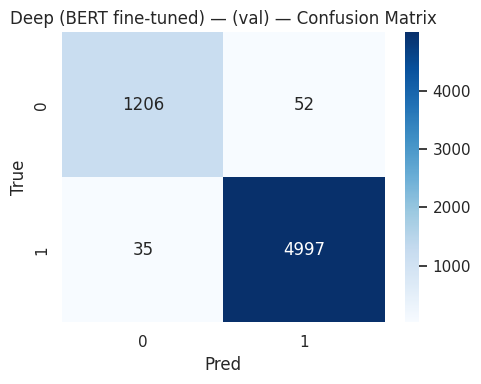

In [ ]:
# -------------------- wrapper (keeps your eval_on_split API) --------------------
class BertWrapper:
    def __init__(self, trainer, tokenizer):
        self.trainer = trainer
        self.tokenizer = tokenizer

    def _to_ds(self, texts):
        if isinstance(texts, pd.DataFrame):
            arr = texts[TEXT_COL].tolist()
        elif isinstance(texts, pd.Series):
            arr = texts.tolist()
        else:
            arr = list(texts)
        ds = HFDataset.from_dict({"text": arr}).map(
            lambda b: self.tokenizer(b["text"], truncation=True, padding="max_length", max_length=256),
            batched=True
        )
        ds.set_format(type="torch", columns=["input_ids", "attention_mask"])
        return ds

    def predict(self, texts):
        ds = self._to_ds(texts)
        preds = self.trainer.predict(ds).predictions
        return np.argmax(preds, axis=1)

    # For ROC-AUC compatibility
    def predict_proba(self, texts):
        ds = self._to_ds(texts)
        logits = self.trainer.predict(ds).predictions
        e = np.exp(logits - logits.max(axis=1, keepdims=True))
        return e / e.sum(axis=1, keepdims=True)

bert_model = BertWrapper(trainer, tokenizer)
bert_val_result = eval_on_split(bert_model, val_df, val_df[LABEL_COL])
show_eval("Deep (BERT fine-tuned) — (val)", bert_val_result, y_va)


# Task 4.4 — Final Evaluation on Test Set


[Baseline:LogReg — (test)] Accuracy: 0.9582 | Precision: 0.9493 | Recall: 0.9175 | F1: 0.9323
              precision    recall  f1-score   support

           0       0.94      0.85      0.89      1258
           1       0.96      0.99      0.97      5033

    accuracy                           0.96      6291
   macro avg       0.95      0.92      0.93      6291
weighted avg       0.96      0.96      0.96      6291



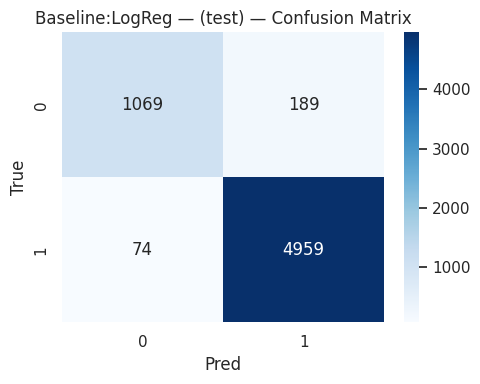

ROC-AUC: 0.9771

[Traditional:RandomForest — (test)] Accuracy: 0.9852 | Precision: 0.9729 | Recall: 0.9815 | F1: 0.9771
              precision    recall  f1-score   support

           0       0.95      0.98      0.96      1258
           1       0.99      0.99      0.99      5033

    accuracy                           0.99      6291
   macro avg       0.97      0.98      0.98      6291
weighted avg       0.99      0.99      0.99      6291



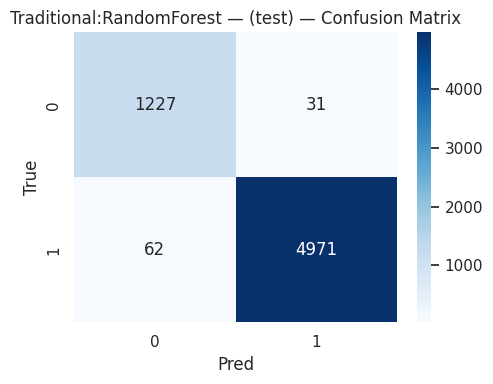

ROC-AUC: 0.9975

[Deep:MLP — (test)] Accuracy: 0.9660 | Precision: 0.9473 | Recall: 0.9462 | F1: 0.9468
              precision    recall  f1-score   support

           0       0.92      0.91      0.91      1258
           1       0.98      0.98      0.98      5033

    accuracy                           0.97      6291
   macro avg       0.95      0.95      0.95      6291
weighted avg       0.97      0.97      0.97      6291



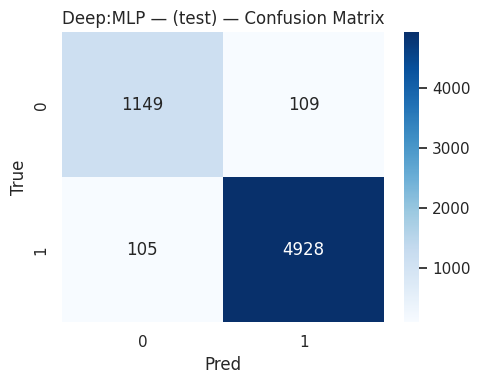

ROC-AUC: 0.9900


Map:   0%|          | 0/6291 [00:00<?, ? examples/s]

Map:   0%|          | 0/6291 [00:00<?, ? examples/s]


[Deep:BERT — (test)] Accuracy: 0.9857 | Precision: 0.9819 | Recall: 0.9732 | F1: 0.9774
              precision    recall  f1-score   support

           0       0.98      0.95      0.96      1258
           1       0.99      0.99      0.99      5033

    accuracy                           0.99      6291
   macro avg       0.98      0.97      0.98      6291
weighted avg       0.99      0.99      0.99      6291



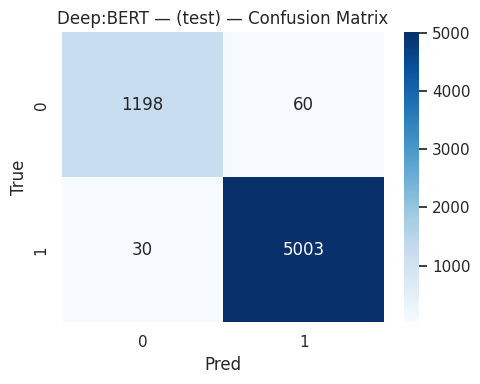

ROC-AUC: 0.9982

=== Test Set Summary (sorted by F1) ===


,model,acc,prec,rec,f1,roc_auc_macro
3,Deep:BERT,0.985694,0.981860,0.973172,0.977441,0.998248
1,Traditional:RandomForest,0.985217,0.972852,0.981520,0.977109,0.997526
2,Deep:MLP,0.965983,0.947314,0.946246,0.946779,0.990011
0,Baseline:LogReg,0.958194,0.949272,0.917529,0.932315,0.977108


In [ ]:
final_candidates = []

# Baseline best
if RUN_BASELINES and best_baseline_name is not None:
    if best_baseline_name == "LogReg":
        final_candidates.append(("Baseline:LogReg", lr_pipe))
    elif best_baseline_name == "GaussianNB":
        final_candidates.append(("Baseline:GaussianNB", nb))

# Traditional best
if RUN_TRADITIONAL and best_trad_model is not None:
    final_candidates.append((f"Traditional:{best_trad_name}", best_trad_model))

# Deep (MLP)
if RUN_MLP and mlp_model is not None:
    final_candidates.append(("Deep:MLP", mlp_model))

# Deep (BERT)
if RUN_BERT and bert_val_result is not None:
    final_candidates.append(("Deep:BERT", bert_model))

# Evaluate on test
summary_rows = []
for name, model in final_candidates:
    # Numeric-feature models expect X; BERT wrapper expects dataframe to read TEXT_COL.
    if name.startswith("Deep:BERT"):
        res = eval_on_split(model, test_df, y_te)   # wrapper reads TEXT_COL internally
        auc = maybe_roc_auc(model, test_df, y_te)
    else:
        res = eval_on_split(model, X_te, y_te)
        auc = maybe_roc_auc(model, X_te, y_te)

    show_eval(f"{name} — (test)", res, y_te)
    print(f"ROC-AUC: {auc:.4f}" if not np.isnan(auc) else "ROC-AUC: N/A")

    summary_rows.append({
        "model": name,
        "acc": res["acc"],
        "prec": res["prec"],
        "rec": res["rec"],
        "f1": res["f1"],
        "roc_auc_macro": auc
    })

summary_df = pd.DataFrame(summary_rows).sort_values("f1", ascending=False)
print("\n=== Test Set Summary (sorted by F1) ===")
display(summary_df)


# Error Analysis (best model)

---



In [ ]:
# Pick the top model on test by F1 (already leakage-safe)
if len(summary_rows) > 0:
    best_on_test = max(summary_rows, key=lambda r: r["f1"])
    best_name = best_on_test["model"]
    print("\nBest on TEST:", best_name)

    # Get predictions to inspect errors
    # Find the object again
    name2model = {n:m for (n,m) in final_candidates}
    best_model = name2model[best_name]

    if best_name.startswith("Deep:BERT"):
        y_pred = best_model.predict(test_df)
    else:
        y_pred = best_model.predict(X_te)

    errs = test_df.copy()
    errs["y_true"] = y_te
    errs["y_pred"] = y_pred
    errs["correct"] = (errs["y_true"] == errs["y_pred"])

    print("\nSome misclassified examples:")
    display(errs.loc[~errs["correct"]].head(20)[[TEXT_COL, "y_true", "y_pred"]])

    print("\nError counts by true label:")
    display(errs.loc[~errs["correct"]].groupby("y_true").size().to_frame("errors"))

    print("\nConfusions (true, pred) top pairs:")
    display(errs.loc[~errs["correct"]].groupby(["y_true","y_pred"]).size().sort_values(ascending=False).head(10))



Best on TEST: Deep:BERT


Map:   0%|          | 0/6291 [00:00<?, ? examples/s]


Some misclassified examples:


,text_clean,y_true,y_pred
14,تكمن مشكلة الشعرية كونها تكتب سيرة ذاتية بدلا ...,1,0
72,تروم الدراسة الكشف العلاقة القلق وعسر الكتابة ...,1,0
126,تتميز شخصية الزعيم الليبي سليمان عبد الله البا...,0,1
128,تعتبر الطاقة مطلب ضروري للتطور الاقتصادي والاج...,0,1
131,تهدف الدراسة التعريف بالنظام المحاسبي المالي ا...,0,1
282,يبحث المقال جهود صانعي ملحمة ثورية الولايتين ا...,0,1
422,يعد واجب الدول دعم استقلال الشعوب مقابل الالتز...,1,0
462,يهدف المقال التعريف بنظرة عبد القاهر الجرجاني ...,0,1
473,المقالة بعنوان مخطوط عرف الريحان التبرك بذكر ا...,1,0
477,المقالة دراسة تحليلية للظواهر الفكرية والاسلوب...,0,1



Error counts by true label:


,errors
y_true,
0,60
1,30



Confusions (true, pred) top pairs:


,,0
y_true,y_pred,
0,1,60
1,0,30
